<h1 style="color: red; text-align: center;">Revision 1</h1>

<h3 style="color: red;">Instructor: Dr. Khaled Mohamad</h3>

---

> **Instructions:** Answer all questions in order, write clean and well-commented code, and **use consistent Markdown formatting** for both questions and answers. It is weighted at 20%.

---

## Dataset overview

You will work with the **Titanic** dataset (built into Seaborn) and the **Tips** dataset (also built into Seaborn). No file uploads are
needed.

---

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


---

<h1 style="color: blue; text-align: center;">Part 1: Load and Explore the Titanic Dataset</h1>

---

## Q1. Load & Inspect
1. Load the Titanic dataset using sns.load_dataset('titanic') and store it in a variable called df .
2. Print the shape of the dataset.
3. Display the first 6 rows.
4. Print the column names.
## ANSWER

In [3]:
# 1)
df = sns.load_dataset('titanic')

# 2)
print("Shape:", df.shape)

# 3)
df.head(6)

Shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True


In [4]:
# 4)
print(df.columns)

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')


---

## Q2. Data Types & Missing Values
1. Use .info() to print column data types and non-null counts.
2. Print the number of missing values per column using .isnull().sum() .
3. Which column has the most missing values? Write your answer in a Markdown cell.
## ANSWER

In [5]:
# 1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [6]:
# 2)
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

Q2.3.Your answer:

Deck has the most missing values, next one is age.

---

## Q3. Basic Statistics
1. Use .describe() to display summary statistics for numeric columns.
2. From the output, answer in a Markdown cell:
What is the mean age of passengers?
What is the maximum fare paid?
What percentage of passengers survived? (Hint: look at the survived mean, it represents the survival rate)
## ANSWER

In [7]:
# 1)
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Answer Q3.2:

- Mean age ≈ 29.7
- Max fare ≈ 512.329
- Survival rate ≈ 0.384 (~38%)

---

## Q4. Duplicates & Categorical Summary
1. Check how many duplicate rows exist in the dataset.
2. Use .describe(include=['object', 'category']) to get a summary of categorical columns.
3. From the output, answer in a Markdown cell:
- What is the most common sex in the dataset and how many rows does it appear in?
- What is the most common embarkation port?
## ANSWER

In [8]:
# 1)
df.duplicated().sum()

107

In [9]:
# 2)
df.describe(include=['object', 'category'])

,sex,embarked,class,who,deck,embark_town,alive
count,891,889,891,891,203,889,891
unique,2,3,3,3,7,3,2
top,male,S,Third,man,C,Southampton,no
freq,577,644,491,537,59,644,549


Answer Q4.3:

Most common sex: male(577)

Most common port: Southhampton(644)

---

<h1 style="color: blue; text-align: center;">Part 2: Data Cleaning</h1>

---

## Q5. Handle Missing Values
Create a new DataFrame called df_clean and apply the following cleaning steps in order:
1. Drop the deck column (too many missing values).
2. Fill missing values in the age column with the median age.
3. Fill missing values in the embarked column with the mode (most frequent value).
4. Fill missing values in the embark_town column with its mode.
5. After cleaning, print .isnull().sum() to confirm no missing values remain.
## ANSWER

In [10]:
df_clean = df.copy()

# 1)
df_clean = df_clean.drop(columns=['deck'])

# 2)
df_clean['age'] = df_clean['age'].fillna(df_clean['age'].median())

# 3)
df_clean['embarked'] = df_clean['embarked'].fillna(df_clean['embarked'].mode()[0])

# 4)
df_clean['embark_town'] = df_clean['embark_town'].fillna(df_clean['embark_town'].mode()[0])

# 5)
df_clean.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

---

## Q6. Remove Duplicates & Redundant Columns
Continue working with df_clean :
1. Remove duplicate rows from df_clean using drop_duplicates(inplace=True) .
2. Drop the columns 'alive' and 'embark_town' - REASON - they are redundant (duplicated information from survived
and embarked ).
3. Print the shape before and after to show how many rows were removed.
4. Display the first 5 rows of the cleaned DataFrame.
## ANSWER

In [11]:
print("Before: ", df_clean.shape)
# 1)
df_clean.drop_duplicates(inplace=True)

# 2)
df_clean.drop(columns=['alive', 'embark_town'])

# 3)
print("After: ", df_clean.shape)

# 4)
df_clean.head()

Before:  (891, 14)
After:  (775, 14)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


---

## Q7. Outlier Detection
1. Create a boxplot for the fare column to visually identify outliers.
2. Use the IQR method to calculate the upper bound for outliers:
Q1 = fare.quantile(0.25) , Q3 = fare.quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
3. Print how many rows have a fare above the upper bound.
4. Create a new column fare_capped that clips the fare at the upper bound using .clip(upper=upper_bound) .
## ANSWER

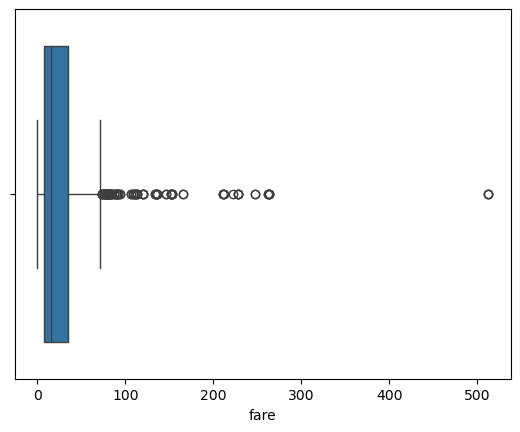

In [12]:
# 1)
sns.boxplot(x=df_clean['fare'])
plt.show()


In [50]:
# 2)
fare = df_clean['fare']

Q1 = fare.quantile(0.25)
Q3 = fare.quantile(0.75)

IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
print("upper_bound: ", upper_bound)

upper_bound:  73.41975000000001


In [51]:
# 3)
print("Rows above upper bound: ", (fare > upper_bound).sum())

Rows above upper bound:  102


In [52]:
# 4)
df_clean['fare_capped'] = df_clean['fare'].clip(upper=upper_bound)

---

<h1 style="color: blue; text-align: center;">Part 3: Filtering, Sorting & Grouping</h1>

---

## Q8. Filtering
Using df_clean :
1. Filter passengers who survived ( survived == 1 ) AND were in First class ( class == 'First' ). How many are there?
2. Filter passengers who were older than 60. Print how many there are and display their names if the column exists, otherwise
display the filtered DataFrame.
3. Filter passengers who paid a fare above $50 and were female. How many rows match?
## ANSWER

In [16]:
# 1)
first_survived = df_clean[(df_clean['survived'] == 1) & (df_clean['class'] == 'First')]
len(first_survived)

133

In [17]:
# 2)
older_60 = df_clean[(df_clean['age'] > 60)]
len(older_60)

21

In [18]:
older_60

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,fare_capped
33,0,2,male,66.0,0,0,10.5000,S,Second,man,True,Southampton,no,True,10.50000
54,0,1,male,65.0,0,1,61.9792,C,First,man,True,Cherbourg,no,False,61.97920
96,0,1,male,71.0,0,0,34.6542,C,First,man,True,Cherbourg,no,True,34.65420
116,0,3,male,70.5,0,0,7.7500,Q,Third,man,True,Queenstown,no,True,7.75000
170,0,1,male,61.0,0,0,33.5000,S,First,man,True,Southampton,no,True,33.50000
252,0,1,male,62.0,0,0,26.5500,S,First,man,True,Southampton,no,True,26.55000
275,1,1,female,63.0,1,0,77.9583,S,First,woman,False,Southampton,yes,False,73.41975
280,0,3,male,65.0,0,0,7.7500,Q,Third,man,True,Queenstown,no,True,7.75000
326,0,3,male,61.0,0,0,6.2375,S,Third,man,True,Southampton,no,True,6.23750
438,0,1,male,64.0,1,4,263.0000,S,First,man,True,Southampton,no,False,73.41975


In [19]:
# 3)
female_50 = df_clean[(df_clean['sex'] == 'female') & (df_clean['fare'] > 50)]
len(female_50)

84

---

## Q9. Sorting
Using df_clean :
1. Sort the DataFrame by fare in descending order and display the top 5 rows (only columns: sex , age , class , fare ,
survived ).
2. Sort by age in ascending order and display the 5 youngest passengers.
3. In a Markdown cell, state one observation from each sorted result. 
## ANSWER

In [20]:
# 1)
df_clean.sort_values(by='fare', ascending=False)[['sex','age','class','fare','survived']].head()

,sex,age,class,fare,survived
258,female,35.0,First,512.3292,1
737,male,35.0,First,512.3292,1
679,male,36.0,First,512.3292,1
88,female,23.0,First,263.0000,1
341,female,24.0,First,263.0000,1


In [21]:
# 2)
df_clean.sort_values(by='age').head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,fare_capped
803,1,3,male,0.42,0,1,8.5167,C,Third,child,False,Cherbourg,yes,False,8.5167
755,1,2,male,0.67,1,1,14.5000,S,Second,child,False,Southampton,yes,False,14.5000
469,1,3,female,0.75,2,1,19.2583,C,Third,child,False,Cherbourg,yes,False,19.2583
831,1,2,male,0.83,1,1,18.7500,S,Second,child,False,Southampton,yes,False,18.7500
78,1,2,male,0.83,0,2,29.0000,S,Second,child,False,Southampton,yes,False,29.0000


Your observations:

The five people who paid more and were in the first class survived and were adults above 23 and below 26.

The youngest passangers were kids under 1 year old and they all survived.    

---

## Q10. GroupBy & Aggregation
Using df_clean :
1. Use .groupby('sex')['survived'].mean() to find the survival rate by sex. Round to 2 decimal places.
2. Use .groupby('class')['survived'].mean() to find the survival rate by passenger class.
3. Use .groupby('class')['fare'].mean() to find the average fare per class.
4. In a Markdown cell, write two observations from the results above.
## ANSWER

In [22]:
# 1)
df_clean.groupby('sex')['survived'].mean().round(2)

sex
female    0.74
male      0.22
Name: survived, dtype: float64

In [23]:
# 2)
df_clean.groupby('class', observed=True)['survived'].mean()

class
First     0.633333
Second    0.506098
Third     0.259352
Name: survived, dtype: float64

In [24]:
# 3)
df_clean.groupby('class', observed=True)['fare'].mean()

class
First     85.675199
Second    21.889279
Third     13.588850
Name: fare, dtype: float64

Your observations:

If you were female, your chance of survival was about three times higher than males.

Passengers in first or second class had survival rates 2 times or more higher than those in third class.

To double your survival chance, you would need to pay only 8 dollars more, but to increase your survival probability by 10%, you would pay an extra 64 dollars.

The difference in fare between first and second class is quite large.

---

<h1 style="color: blue; text-align: center;">Part 4: Visualization</h1>

## Q11. Histogram & Count Plot
Create a figure with two subplots side by side ( figsize=(12, 4) ):
- Left subplot: Histogram of age using sns.histplot with kde=True and bins=20 . Title: 'Age Distribution' .
- Right subplot: Count plot of survived using sns.countplot . Title: 'Survival Count' .

Use plt.tight_layout() and plt.show() .
##  ANSWER

Text(0.5, 1.0, 'Survival Count')

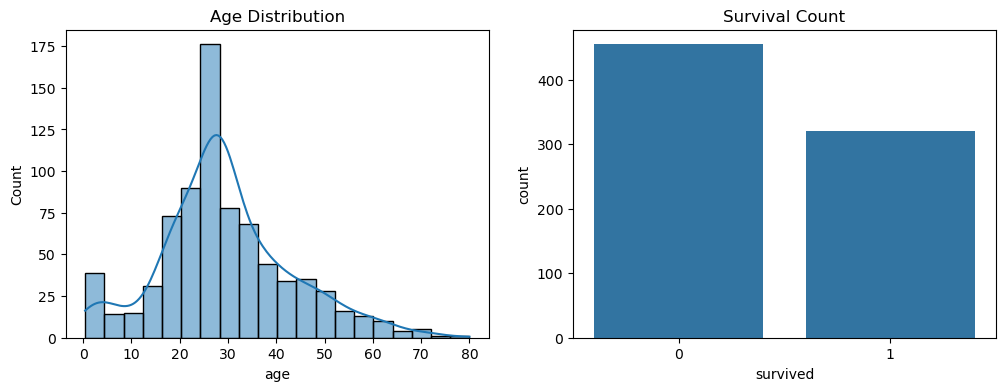

In [25]:
plt.figure(figsize=(12, 4))

plt.subplot(1,2,1)
sns.histplot(x=df_clean['age'], kde=True, bins=20)
plt.title('Age Distribution')

plt.subplot(1,2,2)
sns.countplot(x=df_clean['survived'])
plt.title('Survival Count')

---

## Q12. Categorical Plots
Create a figure with two subplots side by side ( figsize=(12, 5) ):

Left: sns.countplot with x='sex' and hue='survived' . Title: 'Survival by Sex'.

Right: sns.countplot with x='class' and hue='survived' . Title: 'Survival by Class'.

In a Markdown cell below, interpret each plot in one sentence each.
## ANSWER

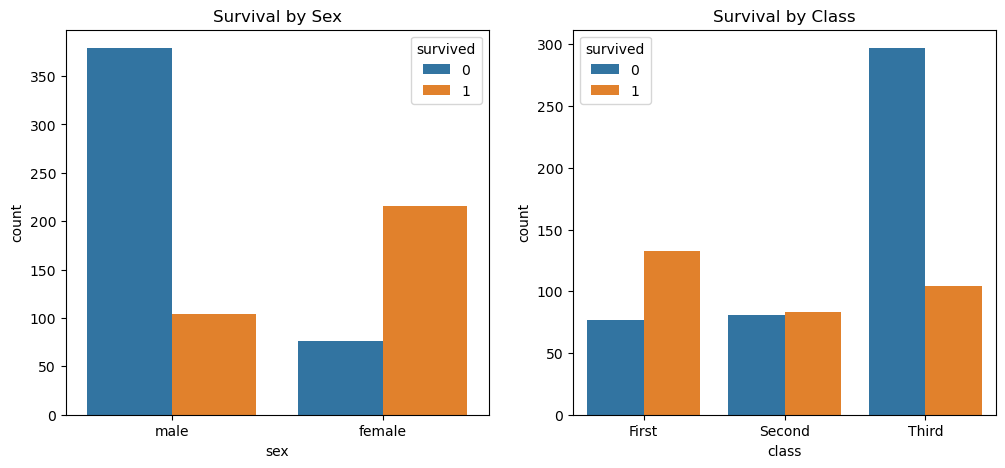

In [26]:
plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
sns.countplot(x='sex', data=df_clean, hue='survived')
plt.title('Survival by Sex')

plt.subplot(1, 2, 2)
sns.countplot(x='class', data=df_clean, hue='survived')
plt.title('Survival by Class')

plt.show()

Your interpretations:
- male passsangers survived less then female ones
- people that were in first class survived more, in second class proportion is almost equal, in third class more people died then survived

---

## Q13. Boxplot & Scatter Plot
1. Create a boxplot using sns.boxplot(x='class', y='age', hue='survived', data=df_clean) . Title: 'Age by Class
and Survival' .
2. Create a scatter plot using sns.scatterplot(x='age', y='fare_capped', hue='survived', data=df_clean,
alpha=0.6) . Title: 'Age vs Fare (Capped) by Survival' .
3. In a Markdown cell, write one observation from each plot.
## ANSWER

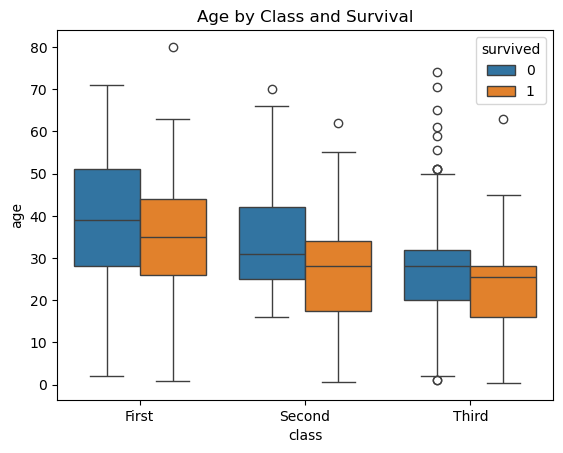

In [27]:
# 1)
sns.boxplot(x='class', y='age', hue='survived', data=df_clean)
plt.title('Age by Class and Survival')

plt.show()

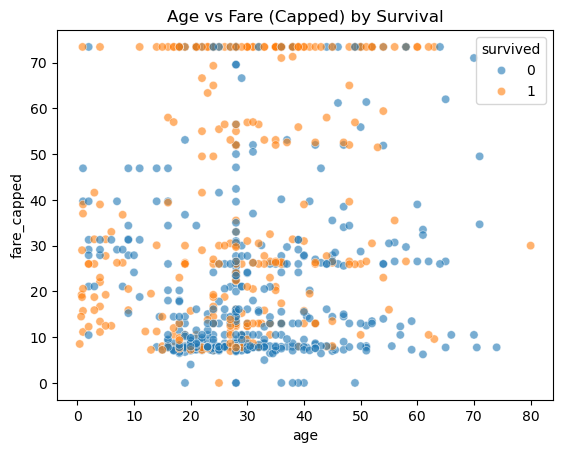

In [28]:
sns.scatterplot(x='age', y='fare_capped', hue='survived', data=df_clean, alpha=0.6)
plt.title('Age vs Fare (Capped) by Survival')

plt.show()

Your observations:

*1*
- Older passengers are more likely to be in higher classes.
- Younger passengers had higher survival rates across all classes.
- Third class has more age outliers despite generally younger passengers.

*2*
- From the left part we can see that children survive more
- From the line on the top we can see that rich people who paid more survived more
- At the bottom with the low fare capped we can see a cloud of blue(not survived) dots
- Vertical lines are the median for age and fare_caped

---

## Q14. Correlation Heatmap
1. Select all numeric columns from df_clean using select_dtypes(include=np.number) .
2. Compute the correlation matrix using .corr() .
3. Plot it as a heatmap using sns.heatmap(... annot=True, cmap='coolwarm', center=0) . Set figsize=(8, 6) . Title: 'Correlation Heatmap' .
4. In a Markdown cell, identify the two features most positively correlated with survival.
## ANSWER

In [29]:
# 1)
numeric_cols = df_clean.select_dtypes(include=np.number)

In [30]:
# 2)
correlation = numeric_cols.corr()

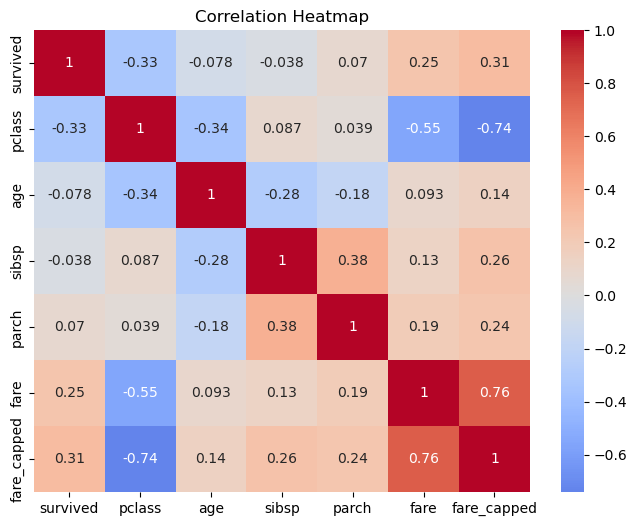

In [47]:
# 3)
plt.figure(figsize=(8, 6))
sns.heatmap(data=correlation, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

Answer Q14.4

From the correlation heatmap we can see that two most importnat features are passanger class(pcalss) and fare. We can see a strong possitive corellation with the fare and strong negative correlation with the pclass.

---

<h1 style="color: blue; text-align: center;">Part 5: Tips Dataset: Filtering & Grouping</h1>

---

## Q15. Load and Filter the Tips Dataset
1. Load the tips dataset: tips = sns.load_dataset('tips') .
2. Display the first 5 rows and print the shape.
3. Filter only dinner orders where the total bill is above $20. How many rows match?
4. From those filtered rows, find the average tip.
## ANSWER

In [32]:
# 1)
tips = sns.load_dataset('tips')

In [33]:
# 2)
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [34]:
# 3)
dinner_20 = tips[(tips['total_bill'] > 20) & (tips['time'] == "Dinner")]
len(dinner_20)

81

In [35]:
# 4)
print("Average: ", dinner_20['total_bill'].mean())

Average:  28.4237037037037


---

## Q16. Grouping the Tips Dataset
Using the full tips DataFrame:
1. Use .groupby('day')['tip'].mean() to find the average tip by day. Sort from highest to lowest.
2. Use .groupby('smoker')['tip'].mean() to compare tips between smokers and non-smokers.
3. In a Markdown cell, answer: Do smokers tip more or less on average?
## ANSWER

In [36]:
# 1)
tips.groupby('day', observed=True)['tip'].mean().sort_values(ascending=False)

day
Sun     3.255132
Sat     2.993103
Thur    2.771452
Fri     2.734737
Name: tip, dtype: float64

In [37]:
# 2)
tips.groupby('smoker', observed=True)['tip'].mean()

smoker
Yes    3.008710
No     2.991854
Name: tip, dtype: float64

Answer Q16.3: Smokers give a little more, but values are almost identical

---

## Q17. Visualize the Tips Dataset
Create a figure with three subplots ( figsize=(15, 4) ):
- Left: Scatter plot of total_bill vs tip (use plt.scatter ). Title: 'Tip vs Total Bill' .
- Center: Bar plot of average tip by day (use .plot(kind='bar') on the grouped result). Title: 'Average Tip by Day' .
- Right: Histogram of tip with bins=15 and edgecolor='k' . Title: 'Tip Distribution'

Add axis labels and plt.tight_layout() .
## ANSWER

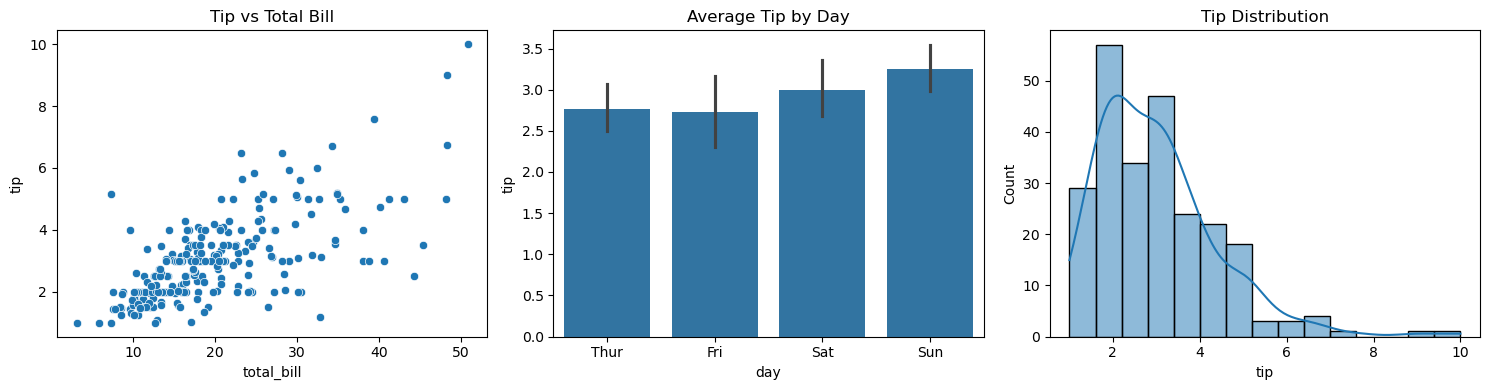

In [38]:
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
sns.scatterplot(x='total_bill', y='tip', data=tips)    # plt.scatter(tips['total_bill'], tips['tip'])
plt.title('Tip vs Total Bill')

plt.subplot(1,3,2)
sns.barplot(data=tips, x='day', y='tip') # tips.groupby('day')['tip'].mean().plot(kind='bar')
plt.title('Average Tip by Day')

plt.subplot(1,3,3)
sns.histplot(x='tip', data=tips, bins=15, edgecolor='k', kde=True) # plt.hist(tips['tip'], bins=15, edgecolor='k')
plt.title('Tip Distribution')

plt.tight_layout()
plt.show()

## Linear Regression on Tips
Using the tips dataset:
1. Extract X = total_bill (reshape to column: tips[['total_bill']].values ) and y = tip( tips[['tip']].values ).
2. Train a LinearRegression model from sklearn.linear_model .
3. Print the coefficient and intercept. Interpret them in a sentence: "For every extra 1 dollar on the bill, the tip increases by..."
4. Plot the data as a scatter plot and overlay the regression line in red.
5. Predict the tip for a total bill of $30.
## ANSWER

In [39]:
from sklearn.linear_model import LinearRegression

# 1)
X = tips[['total_bill']].values
y = y = tips[['tip']].values

In [40]:
# 2)
model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [41]:
# 3)
print("Coefficient: ", model.coef_[0])
print("Intercept:", model.intercept_)

Coefficient:  [0.10502452]
Intercept: [0.92026961]


For every extra 1 dollar on the bill, the tip increases by aproximately 0.105 cents

Text(0.5, 1.0, 'Linear Regression: Total Bill vs Tip')

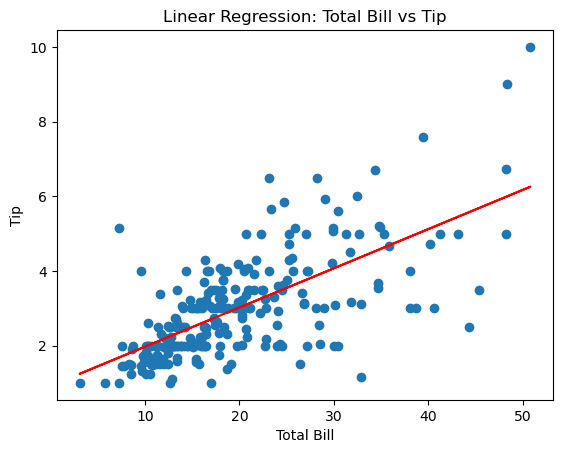

In [45]:
# 4)
plt.scatter(X, y)

y_pred = model.predict(X)
plt.plot(X, y_pred, color='red')

plt.xlabel('Total Bill')
plt.ylabel('Tip')
plt.title('Linear Regression: Total Bill vs Tip')

In [46]:
pred_30 = model.predict([[30]])
print("Predicted tip for $30 bill:", pred_30[0][0])

Predicted tip for $30 bill: 4.071005135085274


In [53]:
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [60]:
X = tips[['total_bill']]
y =  tips[['tip']]

In [61]:
model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [66]:
print(model.coef_)
print(model.intercept)

AttributeError: 'LinearRegression' object has no attribute 'coef'